# 구내식당 식수인원 예측 - V8

## V8 전략
- V7 기반: 참여율(ratio) 예측 방식으로 XGBRegressor 사용
- **신규 추가**: 진주 기상관측소 날씨 데이터(`weather.csv`) 결합
  - 기온, 강수량, 풍속, 습도, 일사량, 적설, 전운량, 지면온도 피처 추가
  - 날씨 피처 결측값 처리 및 파생 변수 생성 (강수 여부, 극한온도 등)
- 목표: Public Score 추가 향상

## 1. 라이브러리 임포트

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error

# 한글 폰트 설정
import sys
sys.path.append('./diner') if './diner' not in sys.path else None

try:
    from korean_font import set_korean_font
    set_korean_font()
except:
    # 직접 폰트 설정
    import platform
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 임포트 완료')

한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)
라이브러리 임포트 완료


## 2. 데이터 로드

In [40]:
# 훈련 데이터 (중앙값으로 공백 채운 버전)
train = pd.read_csv('./data/train_median.csv')
test = pd.read_csv('./data/test.csv')
weather = pd.read_csv('./data/weather.csv', encoding='utf-8-sig')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Weather shape:', weather.shape)
print()
print('Train columns:', train.columns.tolist())
print('Weather columns:', weather.columns.tolist())

Train shape: (1217, 12)
Test shape: (50, 10)
Weather shape: (1826, 11)

Train columns: ['일자', '요일', '본사정원수', '본사휴가자수', '본사출장자수', '본사시간외근무명령서승인건수', '현본사소속재택근무자수', '조식메뉴', '중식메뉴', '석식메뉴', '중식계', '석식계']
Weather columns: ['지점', '지점명', '일시', '기온', '강수량', '풍속', '습도', '일사량', '적설', '전운량', '지면온도']


## 3. 날씨 데이터 전처리

In [41]:
# 날씨 데이터 확인
print('Weather 데이터 샘플:')
print(weather.head())
print()
print('날씨 결측값 현황:')
print(weather.isnull().sum())
print()
print('날씨 데이터 기간:', weather['일시'].min(), '~', weather['일시'].max())

Weather 데이터 샘플:
    지점 지점명          일시   기온  강수량   풍속    습도    일사량  적설  전운량  지면온도
0  192  진주  2016-02-01 -0.6  NaN  1.3  43.9   9.56 NaN  NaN   2.3
1  192  진주  2016-02-02 -2.3  NaN  0.8  47.5  10.40 NaN  NaN   1.2
2  192  진주  2016-02-03 -1.7  NaN  0.6  57.1  10.32 NaN  NaN   1.3
3  192  진주  2016-02-04 -0.2  NaN  0.7  53.4   6.60 NaN  NaN   1.0
4  192  진주  2016-02-05  1.3  NaN  1.0  44.4  10.32 NaN  NaN   2.4

날씨 결측값 현황:
지점         0
지점명        0
일시         0
기온         2
강수량     1237
풍속         1
습도         2
일사량        2
적설      1826
전운량      916
지면온도       8
dtype: int64

날씨 데이터 기간: 2016-02-01 ~ 2021-01-26


In [42]:
# 날씨 데이터 컬럼 한글 처리 (인코딩 문제 대비)
print('Weather columns (raw):', weather.columns.tolist())

# 컬럼명 정리
weather_cols = weather.columns.tolist()
print('Available weather columns:', weather_cols)

Weather columns (raw): ['지점', '지점명', '일시', '기온', '강수량', '풍속', '습도', '일사량', '적설', '전운량', '지면온도']
Available weather columns: ['지점', '지점명', '일시', '기온', '강수량', '풍속', '습도', '일사량', '적설', '전운량', '지면온도']


In [43]:
# 날씨 데이터 전처리
# 컬럼 이름 매핑 (인코딩 문제 있을 수 있어 위치 기반으로도 처리)
weather_clean = weather.copy()

# 날짜 컬럼 처리
date_col = weather_clean.columns[2]  # '일시' 컬럼
weather_clean['일자'] = pd.to_datetime(weather_clean[date_col]).dt.strftime('%Y-%m-%d')

# 사용할 날씨 피처 선택 (위치 기반)
# 컬럼 순서: 지점, 지점명, 일시, 기온, 강수량, 풍속, 습도, 일사량, 적설, 전운량, 지면온도
weather_features = {
    '기온': weather_clean.columns[3],
    '강수량': weather_clean.columns[4],
    '풍속': weather_clean.columns[5],
    '습도': weather_clean.columns[6],
    '일사량': weather_clean.columns[7],
    '전운량': weather_clean.columns[9],
    '지면온도': weather_clean.columns[10],
}

print('날씨 피처 매핑:')
for k, v in weather_features.items():
    print(f'  {k}: {v}')

날씨 피처 매핑:
  기온: 기온
  강수량: 강수량
  풍속: 풍속
  습도: 습도
  일사량: 일사량
  전운량: 전운량
  지면온도: 지면온도


In [44]:
# 날씨 데이터 정리
weather_df = pd.DataFrame()
weather_df['일자'] = weather_clean['일자']

for new_name, orig_col in weather_features.items():
    weather_df[new_name] = pd.to_numeric(weather_clean[orig_col], errors='coerce')

# 중복 날짜 처리 (같은 날짜가 두 번 있으면 평균)
weather_df = weather_df.groupby('일자').mean().reset_index()

print('날씨 정리 후 shape:', weather_df.shape)
print(weather_df.head())
print()
print('결측값:')
print(weather_df.isnull().sum())

날씨 정리 후 shape: (1822, 8)
           일자   기온  강수량   풍속    습도    일사량  전운량  지면온도
0  2016-02-01 -0.6  NaN  1.3  43.9   9.56  NaN   2.3
1  2016-02-02 -2.3  NaN  0.8  47.5  10.40  NaN   1.2
2  2016-02-03 -1.7  NaN  0.6  57.1  10.32  NaN   1.3
3  2016-02-04 -0.2  NaN  0.7  53.4   6.60  NaN   1.0
4  2016-02-05  1.3  NaN  1.0  44.4  10.32  NaN   2.4

결측값:
일자         0
기온         2
강수량     1233
풍속         1
습도         2
일사량        2
전운량      914
지면온도       8
dtype: int64


In [45]:
# 날씨 결측값 처리
# 강수량: 결측=비 안옴(0)으로 채움
weather_df['강수량'] = weather_df['강수량'].fillna(0)

# 기타 결측값: 앞뒤 평균으로 보간
for col in ['기온', '풍속', '습도', '일사량', '전운량', '지면온도']:
    weather_df[col] = (
        weather_df[col]
        .interpolate(method='linear')
        .bfill()
        .ffill()
    )

# 파생 변수 생성
weather_df['강수여부'] = (weather_df['강수량'] > 0).astype(int)
weather_df['극한더위'] = (weather_df['기온'] >= 30).astype(int)   # 폭염 기준
weather_df['극한추위'] = (weather_df['기온'] <= 0).astype(int)    # 영하 기준
weather_df['쾌적날씨'] = ((weather_df['기온'] >= 15) & (weather_df['기온'] <= 25) & (weather_df['강수여부'] == 0)).astype(int)

print('날씨 파생변수 추가 완료')
print(weather_df.head())
print()
print('최종 결측값:')
print(weather_df.isnull().sum())

날씨 파생변수 추가 완료
           일자   기온  강수량   풍속    습도    일사량  전운량  지면온도  강수여부  극한더위  극한추위  쾌적날씨
0  2016-02-01 -0.6  0.0  1.3  43.9   9.56  3.4   2.3     0     0     1     0
1  2016-02-02 -2.3  0.0  0.8  47.5  10.40  3.4   1.2     0     0     1     0
2  2016-02-03 -1.7  0.0  0.6  57.1  10.32  3.4   1.3     0     0     1     0
3  2016-02-04 -0.2  0.0  0.7  53.4   6.60  3.4   1.0     0     0     1     0
4  2016-02-05  1.3  0.0  1.0  44.4  10.32  3.4   2.4     0     0     0     0

최종 결측값:
일자      0
기온      0
강수량     0
풍속      0
습도      0
일사량     0
전운량     0
지면온도    0
강수여부    0
극한더위    0
극한추위    0
쾌적날씨    0
dtype: int64


## 4. 학습 데이터 전처리 및 피처 엔지니어링

In [46]:
def preprocess_data(df, is_train=True):
    """
    V7 기반 전처리 + 날씨 데이터 결합
    """
    data = df.copy()
    
    # 날짜 처리
    data['일자'] = pd.to_datetime(data['일자'])
    data['년'] = data['일자'].dt.year
    data['월'] = data['일자'].dt.month
    data['일'] = data['일자'].dt.day
    data['분기'] = data['일자'].dt.quarter
    data['주차'] = data['일자'].dt.isocalendar().week.astype(int)
    data['일자_str'] = data['일자'].dt.strftime('%Y-%m-%d')  # 날씨 조인용
    
    # 요일 인코딩
    day_map = {'월': 0, '화': 1, '수': 2, '목': 3, '금': 4, '토': 5, '일': 6}
    data['요일_num'] = data['요일'].map(day_map)
    
    # 식사가능자수 계산 (V7 핵심 피처)
    data['식사가능자수'] = (data['본사정원수'] 
                          - data['본사휴가자수'] 
                          - data['본사출장자수'] 
                          - data['현본사소속재택근무자수'])
    data['식사가능자수'] = data['식사가능자수'].clip(lower=0)
    
    # 부재율 계산
    data['휴가율'] = data['본사휴가자수'] / data['본사정원수']
    data['출장율'] = data['본사출장자수'] / data['본사정원수']
    data['재택율'] = data['현본사소속재택근무자수'] / data['본사정원수']
    data['총부재율'] = (data['본사휴가자수'] + data['본사출장자수'] + data['현본사소속재택근무자수']) / data['본사정원수']
    
    # 시간외근무 관련
    data['시간외근무율'] = data['본사시간외근무명령서승인건수'] / data['본사정원수']
    
    # 월별 계절 구분
    data['계절'] = data['월'].map({
        1: 0, 2: 0, 12: 0,  # 겨울
        3: 1, 4: 1, 5: 1,   # 봄
        6: 2, 7: 2, 8: 2,   # 여름
        9: 3, 10: 3, 11: 3  # 가을
    })
    
    return data

train_processed = preprocess_data(train, is_train=True)
test_processed = preprocess_data(test, is_train=False)

print('Train 전처리 완료:', train_processed.shape)
print('Test 전처리 완료:', test_processed.shape)

Train 전처리 완료: (1217, 26)
Test 전처리 완료: (50, 24)


In [47]:
# 날씨 데이터 결합
train_merged = train_processed.merge(weather_df, left_on='일자_str', right_on='일자', how='left')
test_merged = test_processed.merge(weather_df, left_on='일자_str', right_on='일자', how='left')

print('Train 날씨 결합 후:', train_merged.shape)
print('Test 날씨 결합 후:', test_merged.shape)
print()

# 날씨 데이터 결측 확인 (train, test의 날짜가 weather.csv에 없는 경우)
weather_cols_check = ['기온', '강수량', '습도', '일사량', '강수여부']
print('Train 날씨 결측값:')
print(train_merged[weather_cols_check].isnull().sum())
print()
print('Test 날씨 결측값:')
print(test_merged[weather_cols_check].isnull().sum())

Train 날씨 결합 후: (1217, 38)
Test 날씨 결합 후: (50, 36)

Train 날씨 결측값:
기온      0
강수량     0
습도      0
일사량     0
강수여부    0
dtype: int64

Test 날씨 결측값:
기온      50
강수량     50
습도      50
일사량     50
강수여부    50
dtype: int64


In [48]:
# 날씨 결측값 추가 처리 (test 데이터는 2021년으로 weather.csv 범위 밖일 수 있음)
weather_feature_cols = ['기온', '강수량', '풍속', '습도', '일사량', '전운량', '지면온도',
                        '강수여부', '극한더위', '극한추위', '쾌적날씨']

# train에서 월별 평균으로 fill
month_weather_avg = train_merged.groupby('월')[weather_feature_cols].mean()

for col in weather_feature_cols:
    # test 날씨 결측: 해당 월 평균으로 대체
    mask = test_merged[col].isnull()
    if mask.sum() > 0:
        test_merged.loc[mask, col] = test_merged.loc[mask, '월'].map(month_weather_avg[col])
        print(f'{col}: {mask.sum()}개 결측 -> 월별 평균으로 대체')

print('\n결측 처리 후 Test 날씨 결측값:')
print(test_merged[weather_feature_cols].isnull().sum())

기온: 50개 결측 -> 월별 평균으로 대체
강수량: 50개 결측 -> 월별 평균으로 대체
풍속: 50개 결측 -> 월별 평균으로 대체
습도: 50개 결측 -> 월별 평균으로 대체
일사량: 50개 결측 -> 월별 평균으로 대체
전운량: 50개 결측 -> 월별 평균으로 대체
지면온도: 50개 결측 -> 월별 평균으로 대체
강수여부: 50개 결측 -> 월별 평균으로 대체
극한더위: 50개 결측 -> 월별 평균으로 대체
극한추위: 50개 결측 -> 월별 평균으로 대체
쾌적날씨: 50개 결측 -> 월별 평균으로 대체

결측 처리 후 Test 날씨 결측값:
기온      0
강수량     0
풍속      0
습도      0
일사량     0
전운량     0
지면온도    0
강수여부    0
극한더위    0
극한추위    0
쾌적날씨    0
dtype: int64


## 5. 참여율(Ratio) 기반 타겟 변수 생성

In [49]:
# 참여율 계산 (V7 방식)
# 중식 참여율 = 중식계 / 식사가능자수
# 석식 참여율 = 석식계 / 식사가능자수

train_merged['중식_참여율'] = train_merged['중식계'] / train_merged['식사가능자수']
train_merged['석식_참여율'] = train_merged['석식계'] / train_merged['식사가능자수']

# 이상치 처리 (참여율이 0~1.5 범위 벗어나면 제거)
print('중식 참여율 기술통계:')
print(train_merged['중식_참여율'].describe())
print()
print('석식 참여율 기술통계:')
print(train_merged['석식_참여율'].describe())

중식 참여율 기술통계:
count    1217.000000
mean        0.376078
std         0.085139
min         0.143649
25%         0.317570
50%         0.371045
75%         0.432010
max         0.597203
Name: 중식_참여율, dtype: float64

석식 참여율 기술통계:
count    1217.000000
mean        0.195146
std         0.057912
min         0.000000
25%         0.171701
50%         0.203177
75%         0.230073
max         0.380270
Name: 석식_참여율, dtype: float64


In [50]:
# 일부 날의 석식계 = 0 인 경우 제거 (자기계발의날 등)
# 중식: 참여율이 너무 낮거나 높은 케이스 확인
print('석식계 = 0인 행 수:', (train_merged['석식계'] == 0).sum())
print('중식계 = 0인 행 수:', (train_merged['중식계'] == 0).sum())

# 석식 = 0이면 자기계발의날 등으로 보고 훈련에서 제외
train_dinner_valid = train_merged[train_merged['석식계'] > 0].copy()
train_lunch_valid = train_merged[train_merged['중식계'] > 0].copy()

print('\n중식 훈련 데이터:', len(train_lunch_valid))
print('석식 훈련 데이터:', len(train_dinner_valid))

석식계 = 0인 행 수: 43
중식계 = 0인 행 수: 0

중식 훈련 데이터: 1217
석식 훈련 데이터: 1174


## 6. 피처 선택

In [51]:
# 사용할 피처 목록
base_features = [
    # 인원 관련
    '본사정원수',
    '본사휴가자수',
    '본사출장자수',
    '본사시간외근무명령서승인건수',
    '현본사소속재택근무자수',
    '식사가능자수',
    '휴가율',
    '출장율',
    '재택율',
    '총부재율',
    '시간외근무율',
    # 날짜 관련
    '년',
    '월',
    '일',
    '분기',
    '주차',
    '요일_num',
    '계절',
]

# 날씨 피처 추가 (V8 신규)
weather_feats = [
    '기온',
    '강수량',
    '풍속',
    '습도',
    '일사량',
    '전운량',
    '지면온도',
    '강수여부',
    '극한더위',
    '극한추위',
    '쾌적날씨',
]

all_features = base_features + weather_feats
print(f'총 피처 수: {len(all_features)}')
print('피처 목록:', all_features)

총 피처 수: 29
피처 목록: ['본사정원수', '본사휴가자수', '본사출장자수', '본사시간외근무명령서승인건수', '현본사소속재택근무자수', '식사가능자수', '휴가율', '출장율', '재택율', '총부재율', '시간외근무율', '년', '월', '일', '분기', '주차', '요일_num', '계절', '기온', '강수량', '풍속', '습도', '일사량', '전운량', '지면온도', '강수여부', '극한더위', '극한추위', '쾌적날씨']


## 7. 모델 학습 (중식)

In [52]:
# 중식 모델 학습
X_lunch = train_lunch_valid[all_features]
y_lunch = train_lunch_valid['중식_참여율']

print('중식 학습 데이터 shape:', X_lunch.shape)
print('중식 참여율 분포:')
print(y_lunch.describe())

중식 학습 데이터 shape: (1217, 29)
중식 참여율 분포:
count    1217.000000
mean        0.376078
std         0.085139
min         0.143649
25%         0.317570
50%         0.371045
75%         0.432010
max         0.597203
Name: 중식_참여율, dtype: float64


In [53]:
# XGBoost 중식 모델
lunch_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='mae'
)

# 교차검증으로 성능 평가
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_lunch, y_lunch, test_size=0.2, random_state=42)

lunch_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# 검증 성능
val_pred_lunch = lunch_model.predict(X_val)

# 실제 식수 인원으로 변환해서 MAE 확인
val_actual = y_val * X_val['식사가능자수']
val_pred_count = val_pred_lunch * X_val['식사가능자수']

print(f'\n중식 검증 MAE (참여율): {mean_absolute_error(y_val, val_pred_lunch):.4f}')
print(f'중식 검증 MAE (식수인원): {mean_absolute_error(val_actual, val_pred_count):.1f}명')

[0]	validation_0-mae:0.06348


[100]	validation_0-mae:0.03091
[200]	validation_0-mae:0.03061
[272]	validation_0-mae:0.03061

중식 검증 MAE (참여율): 0.0305
중식 검증 MAE (식수인원): 72.3명


In [54]:
# 중식 전체 데이터로 재학습
lunch_model_final = XGBRegressor(
    n_estimators=lunch_model.best_iteration + 50,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
lunch_model_final.fit(X_lunch, y_lunch)
print('중식 최종 모델 학습 완료')
print(f'최적 반복수: {lunch_model.best_iteration}')

중식 최종 모델 학습 완료
최적 반복수: 222


## 8. 모델 학습 (석식)

In [55]:
# 석식 모델 학습
X_dinner = train_dinner_valid[all_features]
y_dinner = train_dinner_valid['석식_참여율']

print('석식 학습 데이터 shape:', X_dinner.shape)
print('석식 참여율 분포:')
print(y_dinner.describe())

석식 학습 데이터 shape: (1174, 29)
석식 참여율 분포:
count    1174.000000
mean        0.202293
std         0.045051
min         0.048235
25%         0.175126
50%         0.205322
75%         0.231210
max         0.380270
Name: 석식_참여율, dtype: float64


In [56]:
# XGBoost 석식 모델
dinner_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='mae'
)

X_tr_d, X_val_d, y_tr_d, y_val_d = train_test_split(X_dinner, y_dinner, test_size=0.2, random_state=42)

dinner_model.fit(
    X_tr_d, y_tr_d,
    eval_set=[(X_val_d, y_val_d)],
    verbose=100
)

# 검증 성능
val_pred_dinner = dinner_model.predict(X_val_d)
val_actual_d = y_val_d * X_val_d['식사가능자수']
val_pred_count_d = val_pred_dinner * X_val_d['식사가능자수']

print(f'\n석식 검증 MAE (참여율): {mean_absolute_error(y_val_d, val_pred_dinner):.4f}')
print(f'석식 검증 MAE (식수인원): {mean_absolute_error(val_actual_d, val_pred_count_d):.1f}명')

[0]	validation_0-mae:0.03646
[100]	validation_0-mae:0.02087
[200]	validation_0-mae:0.02048
[245]	validation_0-mae:0.02052

석식 검증 MAE (참여율): 0.0204
석식 검증 MAE (식수인원): 48.0명


In [57]:
# 석식 전체 데이터로 재학습
dinner_model_final = XGBRegressor(
    n_estimators=dinner_model.best_iteration + 50,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
dinner_model_final.fit(X_dinner, y_dinner)
print('석식 최종 모델 학습 완료')
print(f'최적 반복수: {dinner_model.best_iteration}')

석식 최종 모델 학습 완료
최적 반복수: 195


## 9. 피처 중요도 시각화

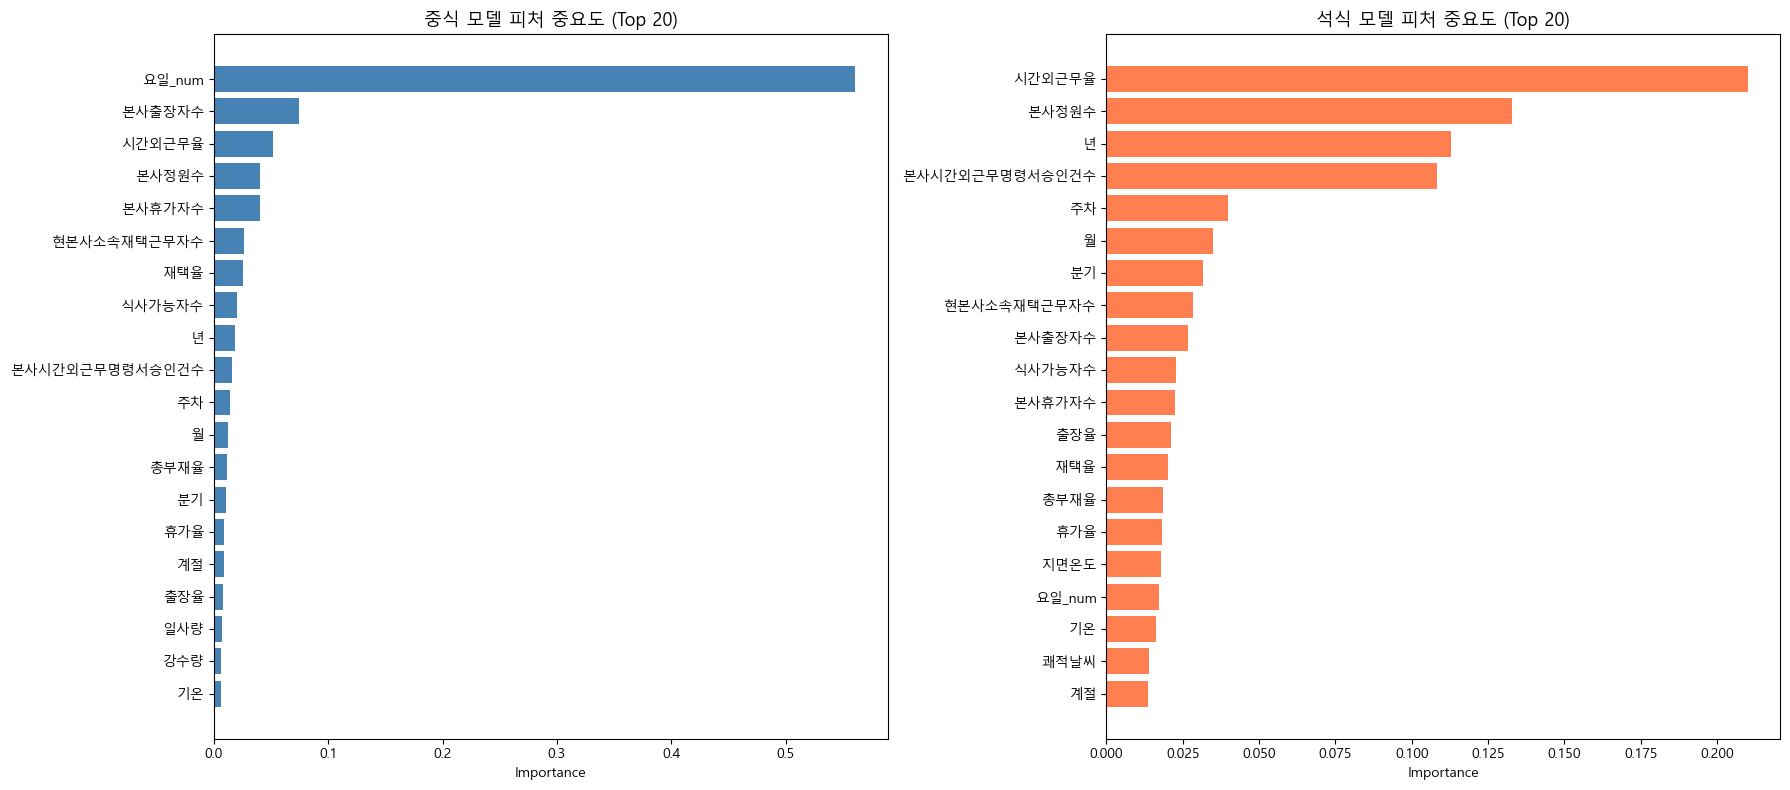

피처 중요도 저장: ./temp/v8_feature_importance.png


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 중식 피처 중요도
lunch_importance = pd.DataFrame({
    'feature': all_features,
    'importance': lunch_model_final.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

axes[0].barh(lunch_importance['feature'], lunch_importance['importance'], color='steelblue')
axes[0].set_title('중식 모델 피처 중요도 (Top 20)', fontsize=13)
axes[0].set_xlabel('Importance')

# 석식 피처 중요도
dinner_importance = pd.DataFrame({
    'feature': all_features,
    'importance': dinner_model_final.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

axes[1].barh(dinner_importance['feature'], dinner_importance['importance'], color='coral')
axes[1].set_title('석식 모델 피처 중요도 (Top 20)', fontsize=13)
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('./temp/v8_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print('피처 중요도 저장: ./temp/v8_feature_importance.png')

## 10. 날씨 피처의 영향 분석

In [59]:
# 날씨 피처 중요도 비교
print('=== 날씨 피처 중요도 (중식 모델) ===')
lunch_feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': lunch_model_final.feature_importances_
})
weather_imp = lunch_feat_imp[lunch_feat_imp['feature'].isin(weather_feats)].sort_values('importance', ascending=False)
print(weather_imp.to_string())

print()
print('=== 날씨 피처 중요도 (석식 모델) ===')
dinner_feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': dinner_model_final.feature_importances_
})
weather_imp_d = dinner_feat_imp[dinner_feat_imp['feature'].isin(weather_feats)].sort_values('importance', ascending=False)
print(weather_imp_d.to_string())

=== 날씨 피처 중요도 (중식 모델) ===
   feature  importance
22     일사량    0.006902
19     강수량    0.006366
18      기온    0.006289
21      습도    0.006207
24    지면온도    0.006115
23     전운량    0.005281
28    쾌적날씨    0.004203
20      풍속    0.003869
25    강수여부    0.003053
27    극한추위    0.000705
26    극한더위    0.000000

=== 날씨 피처 중요도 (석식 모델) ===
   feature  importance
24    지면온도    0.017701
18      기온    0.016350
28    쾌적날씨    0.014007
25    강수여부    0.011605
20      풍속    0.011209
22     일사량    0.010107
19     강수량    0.009975
21      습도    0.009162
23     전운량    0.007599
27    극한추위    0.001019
26    극한더위    0.000000


## 11. 테스트 예측 및 제출 파일 생성

In [60]:
# 테스트 데이터 예측
X_test = test_merged[all_features]

# 예측 (참여율)
test_lunch_ratio = lunch_model_final.predict(X_test)
test_dinner_ratio = dinner_model_final.predict(X_test)

# 클리핑 (참여율은 0 이상이어야 함)
test_lunch_ratio = np.clip(test_lunch_ratio, 0, None)
test_dinner_ratio = np.clip(test_dinner_ratio, 0, None)

# 식수인원으로 변환
test_lunch_count = test_lunch_ratio * test_merged['식사가능자수']
test_dinner_count = test_dinner_ratio * test_merged['식사가능자수']

# 반올림 (정수로)
test_lunch_count = np.round(test_lunch_count).astype(int)
test_dinner_count = np.round(test_dinner_count).astype(int)

print('중식 예측 통계:')
print(pd.Series(test_lunch_count).describe())
print()
print('석식 예측 통계:')
print(pd.Series(test_dinner_count).describe())

중식 예측 통계:
count      50.000000
mean      968.840000
std       215.154084
min       588.000000
25%       844.500000
50%       997.500000
75%      1108.250000
max      1319.000000
Name: 식사가능자수, dtype: float64

석식 예측 통계:
count     50.000000
mean     483.700000
std      136.364645
min      250.000000
25%      382.500000
50%      453.500000
75%      611.500000
max      716.000000
Name: 식사가능자수, dtype: float64


In [61]:
# 제출 파일 생성
sample_submission = pd.read_csv('./data/sample_submission.csv')
print('Sample submission shape:', sample_submission.shape)
print(sample_submission.head())

Sample submission shape: (50, 3)
           일자  중식계  석식계
0  2021-01-27    0    0
1  2021-01-28    0    0
2  2021-01-29    0    0
3  2021-02-01    0    0
4  2021-02-02    0    0


In [62]:
submission = sample_submission.copy()

# 제출 파일 컬럼 확인 및 채우기
print('Submission 컬럼:', submission.columns.tolist())

submission['중식계'] = test_lunch_count
submission['석식계'] = test_dinner_count

# 저장
submission.to_csv('./submission/submission_v8.csv', index=False, encoding='utf-8-sig')
print('제출 파일 저장 완료: ./submission/submission_v8.csv')
print()
print(submission.head(10))

Submission 컬럼: ['일자', '중식계', '석식계']
제출 파일 저장 완료: ./submission/submission_v8.csv

           일자   중식계  석식계
0  2021-01-27  1046  364
1  2021-01-28   958  402
2  2021-01-29   658  250
3  2021-02-01  1264  543
4  2021-02-02  1032  453
5  2021-02-03  1018  434
6  2021-02-04  1016  452
7  2021-02-05   664  363
8  2021-02-08  1282  670
9  2021-02-09  1119  508


## 12. 예측 결과 시각화

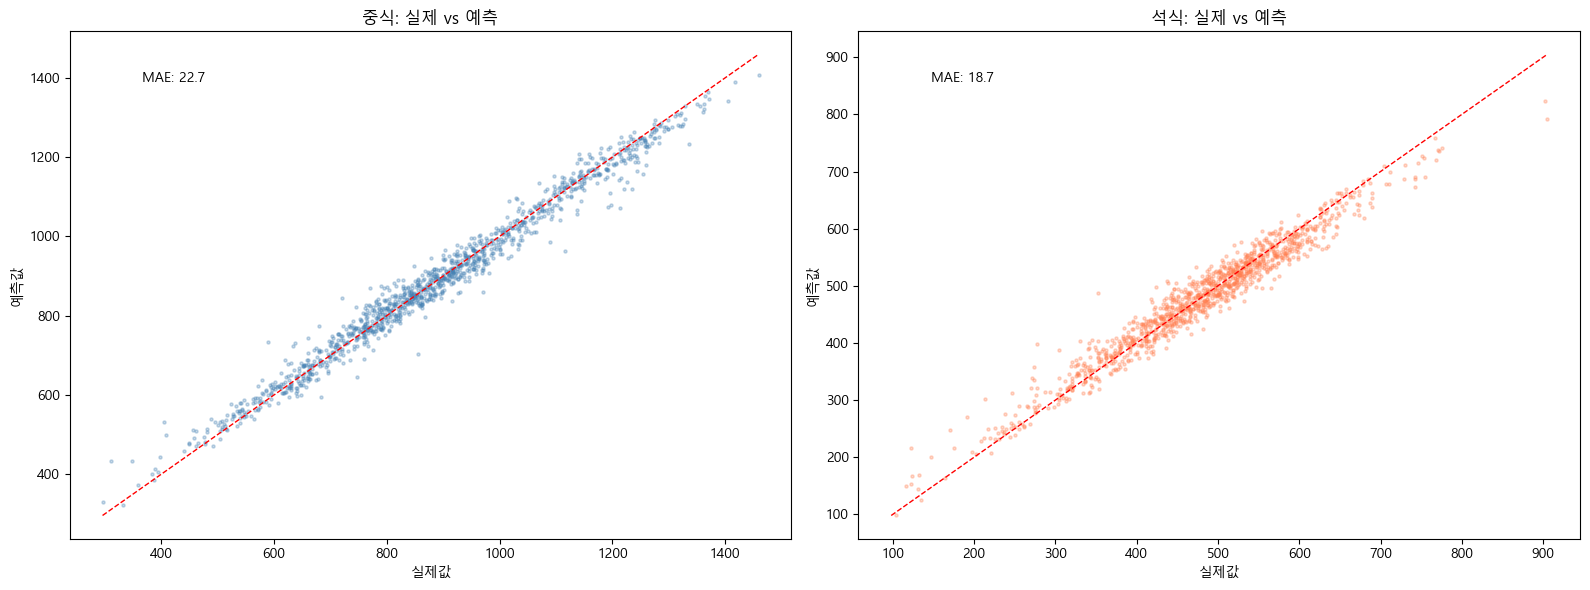

In [63]:
# 학습 데이터에서 예측 vs 실제 비교
train_lunch_pred_ratio = lunch_model_final.predict(train_lunch_valid[all_features])
train_lunch_pred = train_lunch_pred_ratio * train_lunch_valid['식사가능자수']

train_dinner_pred_ratio = dinner_model_final.predict(train_dinner_valid[all_features])
train_dinner_pred = train_dinner_pred_ratio * train_dinner_valid['식사가능자수']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 중식
axes[0].scatter(train_lunch_valid['중식계'], train_lunch_pred, alpha=0.3, s=5, color='steelblue')
min_val = min(train_lunch_valid['중식계'].min(), train_lunch_pred.min())
max_val = max(train_lunch_valid['중식계'].max(), train_lunch_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
axes[0].set_title('중식: 실제 vs 예측')
axes[0].set_xlabel('실제값')
axes[0].set_ylabel('예측값')
axes[0].text(0.1, 0.9, f'MAE: {mean_absolute_error(train_lunch_valid["중식계"], train_lunch_pred):.1f}',
             transform=axes[0].transAxes)

# 석식
axes[1].scatter(train_dinner_valid['석식계'], train_dinner_pred, alpha=0.3, s=5, color='coral')
min_val = min(train_dinner_valid['석식계'].min(), train_dinner_pred.min())
max_val = max(train_dinner_valid['석식계'].max(), train_dinner_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
axes[1].set_title('석식: 실제 vs 예측')
axes[1].set_xlabel('실제값')
axes[1].set_ylabel('예측값')
axes[1].text(0.1, 0.9, f'MAE: {mean_absolute_error(train_dinner_valid["석식계"], train_dinner_pred):.1f}',
             transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('./temp/v8_actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

## 13. 날씨별 참여율 분석

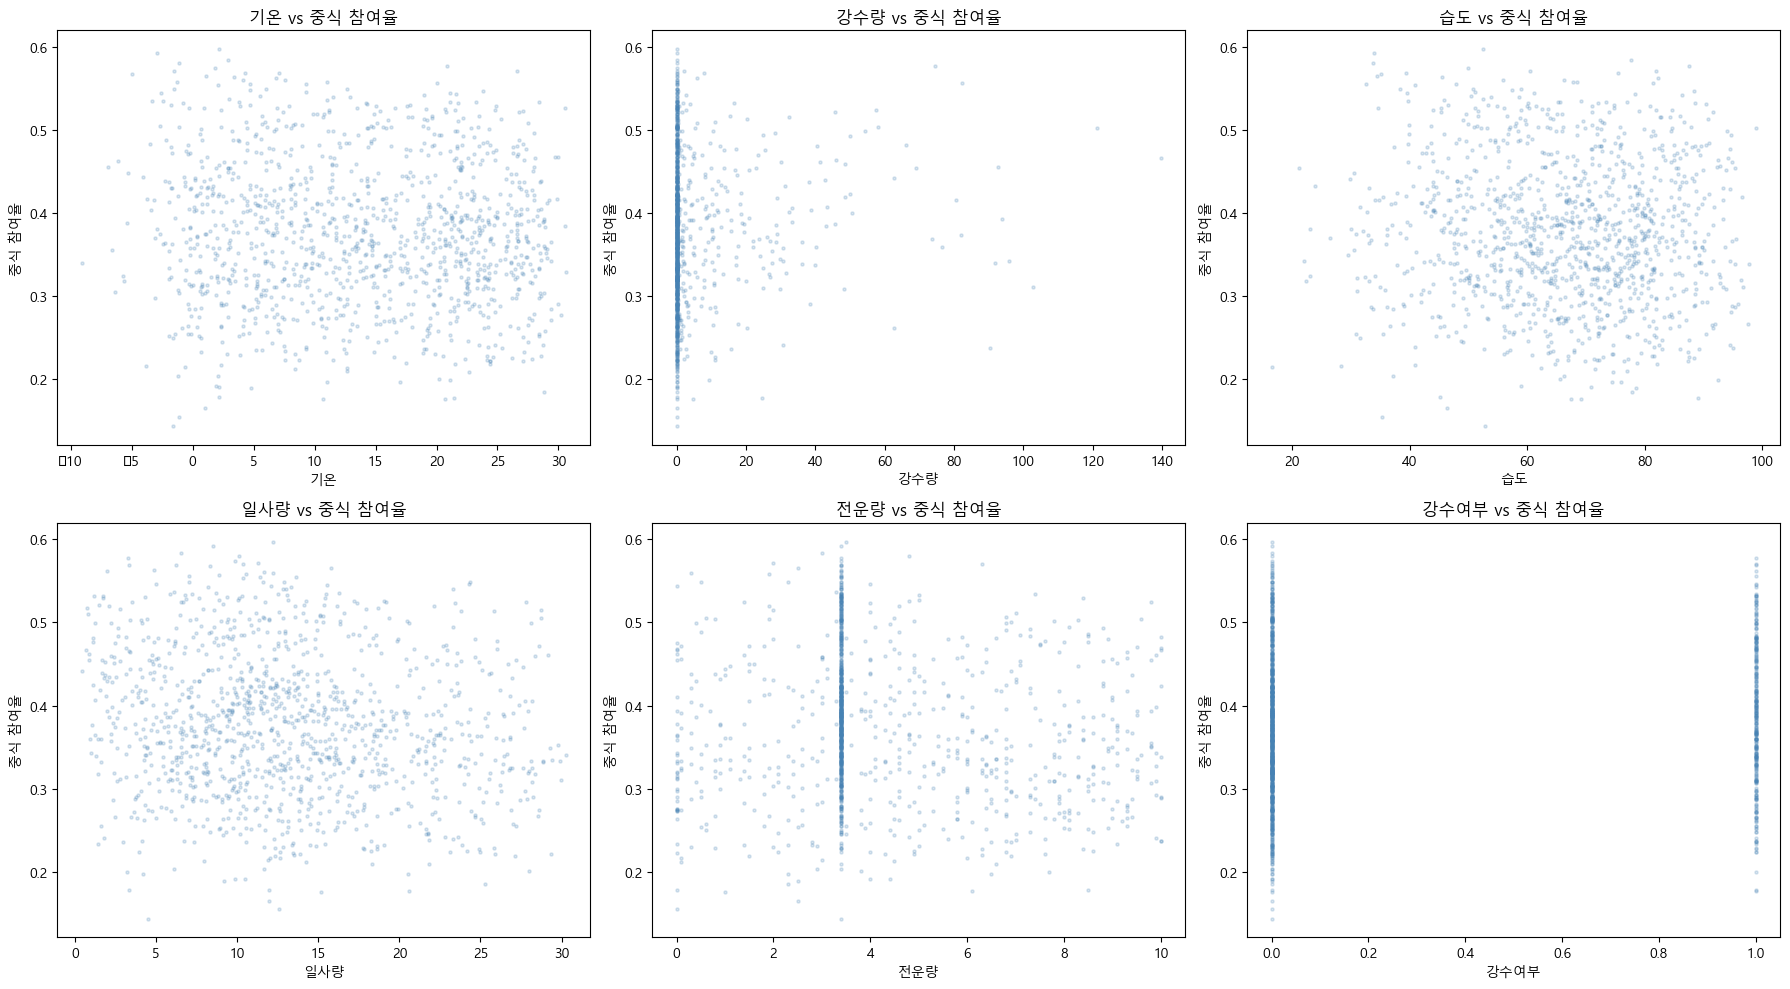

날씨 분석 저장: ./temp/v8_weather_analysis.png


In [64]:
# 날씨와 참여율의 관계 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

weather_analysis_cols = ['기온', '강수량', '습도', '일사량', '전운량', '강수여부']

for idx, col in enumerate(weather_analysis_cols):
    ax = axes[idx//3][idx%3]
    if col in train_lunch_valid.columns:
        ax.scatter(train_lunch_valid[col], train_lunch_valid['중식_참여율'], 
                   alpha=0.2, s=5, color='steelblue', label='중식')
        ax.set_xlabel(col)
        ax.set_ylabel('중식 참여율')
        ax.set_title(f'{col} vs 중식 참여율')

plt.tight_layout()
plt.savefig('./temp/v8_weather_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('날씨 분석 저장: ./temp/v8_weather_analysis.png')

In [65]:
# 강수 여부에 따른 참여율 차이
print('=== 강수 여부에 따른 참여율 차이 ===')
rain_analysis = train_lunch_valid.groupby('강수여부').agg(
    중식_참여율_평균=('중식_참여율', 'mean'),
    건수=('중식_참여율', 'count')
)
print(rain_analysis)
print()

# 계절별 참여율
season_map = {0: '겨울', 1: '봄', 2: '여름', 3: '가을'}
print('=== 계절별 참여율 ===')
season_analysis = train_lunch_valid.groupby('계절')['중식_참여율'].mean()
season_analysis.index = season_analysis.index.map(season_map)
print(season_analysis)

=== 강수 여부에 따른 참여율 차이 ===
      중식_참여율_평균   건수
강수여부                
0      0.372043  901
1      0.387583  316

=== 계절별 참여율 ===
계절
겨울    0.383550
봄     0.385056
여름    0.368039
가을    0.367869
Name: 중식_참여율, dtype: float64


## 14. 최종 결과 요약

In [66]:
# 전체 학습 데이터 MAE 요약
overall_lunch_mae = mean_absolute_error(train_lunch_valid['중식계'], train_lunch_pred)
overall_dinner_mae = mean_absolute_error(train_dinner_valid['석식계'], train_dinner_pred)
overall_mae = (overall_lunch_mae + overall_dinner_mae) / 2

print('=' * 50)
print('V8 모델 학습 결과 요약')
print('=' * 50)
print(f'중식 MAE: {overall_lunch_mae:.2f}명')
print(f'석식 MAE: {overall_dinner_mae:.2f}명')
print(f'전체 평균 MAE: {overall_mae:.2f}명')
print()
print('날씨 피처 추가 개선 사항:')
print('  - 기온, 강수량, 습도, 일사량, 전운량, 지면온도 추가')
print('  - 파생변수: 강수여부, 극한더위, 극한추위, 쾌적날씨')
print()
print(f'제출 파일: ./submission/submission_v8.csv')

V8 모델 학습 결과 요약
중식 MAE: 22.68명
석식 MAE: 18.69명
전체 평균 MAE: 20.68명

날씨 피처 추가 개선 사항:
  - 기온, 강수량, 습도, 일사량, 전운량, 지면온도 추가
  - 파생변수: 강수여부, 극한더위, 극한추위, 쾌적날씨

제출 파일: ./submission/submission_v8.csv


In [67]:
# 제출 파일 최종 확인
final_sub = pd.read_csv('./submission/submission_v8.csv')
print('제출 파일 확인:')
print(final_sub.head(10))
print()
print('총 예측 행 수:', len(final_sub))
print('결측값 확인:', final_sub.isnull().sum().sum())

제출 파일 확인:
           일자   중식계  석식계
0  2021-01-27  1046  364
1  2021-01-28   958  402
2  2021-01-29   658  250
3  2021-02-01  1264  543
4  2021-02-02  1032  453
5  2021-02-03  1018  434
6  2021-02-04  1016  452
7  2021-02-05   664  363
8  2021-02-08  1282  670
9  2021-02-09  1119  508

총 예측 행 수: 50
결측값 확인: 0
